In [1]:
pip install -q fastapi uvicorn pyngrok nest-asyncio joblib scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

load and inspect data

In [7]:
df = pd.read_csv("/content/cleaned_data.csv", engine='python')

In [9]:
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))
print("\nTopic distribution:\n",   df["topic"].value_counts())
print("\nSentiment distribution:\n", df["sentiment"].value_counts())

Shape: (38520, 6)

Column types:
 id             int64
topic         object
sentiment     object
text          object
tokens        object
clean_text    object
dtype: object

First 3 rows:
      id        topic sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   

                                                text  \
0  i am coming to the borders and i will kill you...   
1  im getting on borderlands and i will kill you all   
2  im coming on borderlands and i will murder you...   

                                      tokens                    clean_text  
0              ['coming', 'borders', 'kill']           coming borders kill  
1   ['im', 'getting', 'borderlands', 'kill']   im getting borderlands kill  
2  ['im', 'coming', 'borderlands', 'murder']  im coming borderlands murder  

Topic distribution:
 topic
Microsoft                    2400
LeagueOfLegends              2394
CallOfDutyBlackopsColdWar    2376
ApexLegend

pre processing

In [10]:
df = df.dropna(subset=["clean_text", "topic", "sentiment"])

X = df["clean_text"].astype(str)

# Target 1 → Department (topic)
y_topic = df["topic"].astype(str)

# Target 2 → Priority (sentiment mapped to numeric score)
priority_map = {
    "Positive":    1,
    "Neutral":     2,
    "Negative":    3,
    "Irrelevant":  0,
}
y_sentiment = df["sentiment"].map(priority_map).fillna(0).astype(int)

print("Features shape:", X.shape)
print("Unique departments:", y_topic.nunique())
print("Priority score classes:", sorted(y_sentiment.unique()))

Features shape: (37295,)
Unique departments: 17
Priority score classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


train and test

In [11]:
X_train, X_test, yt_train, yt_test, ys_train, ys_test = train_test_split(
    X, y_topic, y_sentiment,
    test_size=0.2,
    random_state=42,
    stratify=y_topic,
)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 29836  |  Test: 7459


build and train pipeline

In [12]:
# -- Department / Topic model --
topic_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        C=5.0,
        solver="lbfgs",
        multi_class="auto",
        n_jobs=-1,
    )),
])

# -- Priority / Sentiment model --
sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        C=5.0,
        solver="lbfgs",
        multi_class="auto",
        n_jobs=-1,
    )),
])

print("Training Department model...")
topic_pipeline.fit(X_train, yt_train)

print("Training Sentiment/Priority model...")
sentiment_pipeline.fit(X_train, ys_train)

print("✅ Both models trained.")

Training Department model...
Training Sentiment/Priority model...
✅ Both models trained.


evaluation : department

DEPARTMENT (TOPIC) — Classification Report
                           precision    recall  f1-score   support

                   Amazon       0.97      0.95      0.96       449
              ApexLegends       0.92      0.91      0.91       457
           AssassinsCreed       0.91      0.90      0.90       440
              Borderlands       0.98      0.92      0.95       442
                    CS-GO       0.95      0.91      0.93       443
CallOfDutyBlackopsColdWar       0.80      0.91      0.85       458
                    Dota2       0.89      0.89      0.89       465
                 Fortnite       0.92      0.90      0.91       442
                   Google       0.96      0.93      0.94       445
              Hearthstone       0.96      0.93      0.95       230
          LeagueOfLegends       0.93      0.94      0.93       460
                Microsoft       0.93      0.94      0.93       462
                    NBA2K       0.96      0.92      0.94       458
                Ov

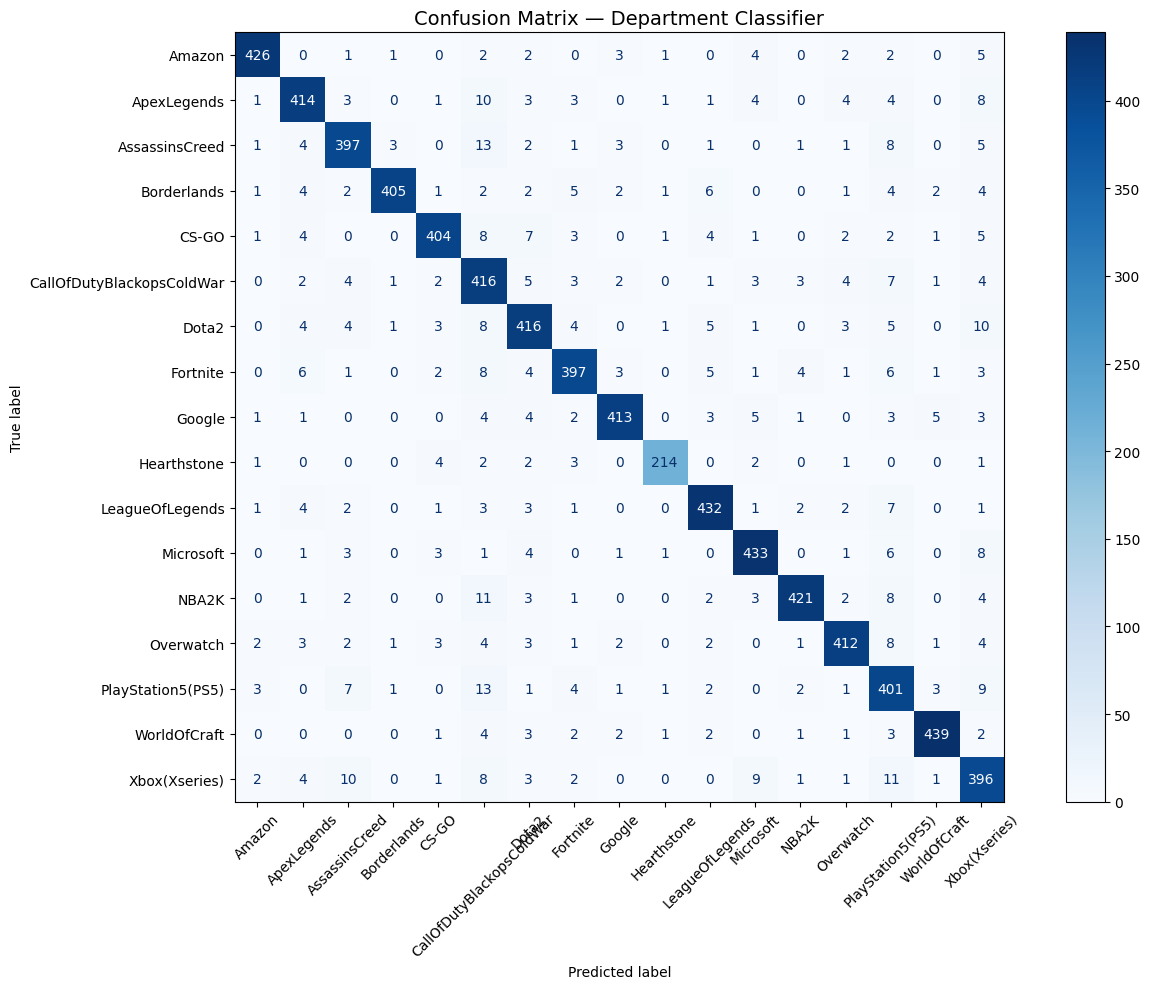

Saved: confusion_matrix_department.png


In [13]:
yt_pred = topic_pipeline.predict(X_test)

print("=" * 60)
print("DEPARTMENT (TOPIC) — Classification Report")
print("=" * 60)
print(classification_report(yt_test, yt_pred))

# Confusion Matrix
cm_topic = confusion_matrix(yt_test, yt_pred, labels=topic_pipeline.classes_)
fig, ax = plt.subplots(figsize=(14, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_topic,
    display_labels=topic_pipeline.classes_,
)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Department Classifier", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrix_department.png", dpi=150)
plt.show()
print("Saved: confusion_matrix_department.png")

evaluation : sentiment


PRIORITY (SENTIMENT) — Classification Report
              precision    recall  f1-score   support

  Irrelevant       0.94      0.89      0.92      1358
    Negative       0.94      0.94      0.94      1958
     Neutral       0.92      0.92      0.92      1895
    Positive       0.91      0.94      0.93      2248

    accuracy                           0.92      7459
   macro avg       0.93      0.92      0.92      7459
weighted avg       0.92      0.92      0.92      7459



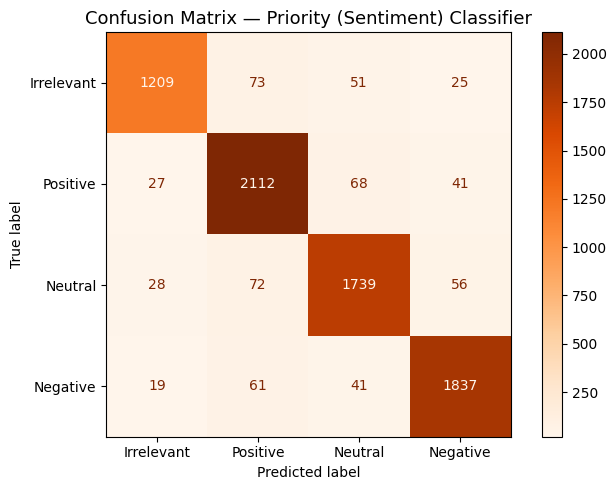

Saved: confusion_matrix_priority.png


In [14]:
ys_pred = sentiment_pipeline.predict(X_test)

# Inverse map for readable labels
inv_priority = {v: k for k, v in priority_map.items()}
ys_test_labels = [inv_priority[i] for i in ys_test]
ys_pred_labels = [inv_priority[i] for i in ys_pred]

print("=" * 60)
print("PRIORITY (SENTIMENT) — Classification Report")
print("=" * 60)
print(classification_report(ys_test_labels, ys_pred_labels))

# Confusion Matrix
sentiment_labels = ["Irrelevant", "Positive", "Neutral", "Negative"]
cm_sent = confusion_matrix(ys_test_labels, ys_pred_labels, labels=sentiment_labels)
fig, ax = plt.subplots(figsize=(7, 5))
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_sent,
    display_labels=sentiment_labels,
)
disp2.plot(ax=ax, colorbar=True, cmap="Oranges")
ax.set_title("Confusion Matrix — Priority (Sentiment) Classifier", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_priority.png", dpi=150)
plt.show()
print("Saved: confusion_matrix_priority.png")

serialize model

In [15]:
joblib.dump(topic_pipeline,     "department_model.joblib")
joblib.dump(sentiment_pipeline, "priority_model.joblib")
joblib.dump(priority_map,       "priority_map.joblib")

print(" Models saved:")
print("   department_model.joblib")
print("   priority_model.joblib")
print("   priority_map.joblib")

 Models saved:
   department_model.joblib
   priority_model.joblib
   priority_map.joblib


fast API application

In [16]:
api_code = '''
import joblib
from fastapi import FastAPI
from pydantic import BaseModel

# Load serialized models
department_model = joblib.load("department_model.joblib")
priority_model   = joblib.load("priority_model.joblib")
priority_map     = joblib.load("priority_map.joblib")

inv_priority = {v: k for k, v in priority_map.items()}

app = FastAPI(
    title="Citizen Complaint Classifier API",
    description="Predicts the department and priority score from a raw text complaint.",
    version="1.0.0",
)

class ComplaintRequest(BaseModel):
    complaint: str

class ComplaintResponse(BaseModel):
    department: str
    priority_score: int
    priority_label: str

@app.get("/")
def root():
    return {"status": "ok", "message": "Complaint Classifier API is running."}

@app.post("/predict", response_model=ComplaintResponse)
def predict(payload: ComplaintRequest):
    text = [payload.complaint]

    department   = department_model.predict(text)[0]
    priority_num = int(priority_model.predict(text)[0])
    priority_lbl = inv_priority.get(priority_num, "Unknown")

    return ComplaintResponse(
        department=department,
        priority_score=priority_num,
        priority_label=priority_lbl,
    )

@app.get("/departments")
def list_departments():
    return {"departments": list(department_model.classes_)}
'''

with open("app.py", "w") as f:
    f.write(api_code)

print(" FastAPI app written to app.py")

 FastAPI app written to app.py


launch fastAPI

In [17]:
launch_code = """
import nest_asyncio
import uvicorn
from pyngrok import ngrok

# ── Set your ngrok auth token (free at https://ngrok.com) ──
ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN_HERE")   # ← replace this

nest_asyncio.apply()

# Open public tunnel on port 8000
public_url = ngrok.connect(8000)
print(" Public API URL:", public_url)
print("   Swagger docs:  ", public_url, "/docs")

# Start the server (runs in the Colab cell, blocking)
uvicorn.run("app:app", host="0.0.0.0", port=8000)
"""

print("=" * 60)
print("CELL 11 — Copy the code below into a NEW Colab cell and run it:")
print("=" * 60)
print(launch_code)

CELL 11 — Copy the code below into a NEW Colab cell and run it:

import nest_asyncio
import uvicorn
from pyngrok import ngrok
 
# ── Set your ngrok auth token (free at https://ngrok.com) ──
ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN_HERE")   # ← replace this
 
nest_asyncio.apply()
 
# Open public tunnel on port 8000
public_url = ngrok.connect(8000)
print(" Public API URL:", public_url)
print("   Swagger docs:  ", public_url, "/docs")
 
# Start the server (runs in the Colab cell, blocking)
uvicorn.run("app:app", host="0.0.0.0", port=8000)



test the api

In [18]:
test_code = """
import requests

BASE_URL = "http://localhost:8000"   # or paste your ngrok URL

payload = {"complaint": "The game keeps crashing every time I try to load a match on Overwatch"}

resp = requests.post(f"{BASE_URL}/predict", json=payload)
print(resp.status_code)
print(resp.json())
# Expected output example:
# {'department': 'Overwatch', 'priority_score': 3, 'priority_label': 'Negative'}
"""

print("=" * 60)
print("CELL 12 — Test the running API (paste in a new cell):")
print("=" * 60)
print(test_code)

CELL 12 — Test the running API (paste in a new cell):

import requests
 
BASE_URL = "http://localhost:8000"   # or paste your ngrok URL
 
payload = {"complaint": "The game keeps crashing every time I try to load a match on Overwatch"}
 
resp = requests.post(f"{BASE_URL}/predict", json=payload)
print(resp.status_code)
print(resp.json())
# Expected output example:
# {'department': 'Overwatch', 'priority_score': 3, 'priority_label': 'Negative'}

